# Social Media, Dopamine and Productivity Data Analysis

## Install dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn

## Dataset

In [2]:
df = pd.read_csv("../../datasets/social_media_dopamine_productivity.csv")
df.head(3)

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,...,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
0,P0001,synthetic_ai,1,16,13-17,Female,South Asian,Indian,India,High school,...,Yes,9,2,3,Boredom,Critical,8.8,9.2,2.1,9.5
1,P0002,synthetic_ai,1,17,13-17,Male,East Asian,Chinese,China,High school,...,Yes,10,1,1,Curiosity,Critical,9.5,9.8,1.5,9.8
2,P0003,synthetic_ai,1,15,13-17,Female,Black/African,Nigerian,Nigeria,High school,...,Yes,8,2,5,Boredom,Severe,8.0,8.5,2.8,9.0


In [ ]:
df = pd.read_csv("../../datasets/social_media_dopamine_productivity.csv", header=None)
#Cleaning
row = df.iloc[0].tolist()
row.insert(57, "mood_dependency_on_sm_score")
row.remove("notes")
df.columns = row
df.drop(index=0, axis=0, inplace=True)

df=df.drop(['data_source','synthetic_flag'], axis=1)
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    if converted.notna().sum() == df[col].notna().sum():
        df[col] = converted
print("First 3 records:", df.head(3))

First 3 records:   participant_id  age age_group  gender race_ethnicity nationality  \
1          P0001   16     13-17  Female    South Asian      Indian   
2          P0002   17     13-17    Male     East Asian     Chinese   
3          P0003   15     13-17  Female  Black/African    Nigerian   

  country_of_residence education_level employment_status occupation_category  \
1                India     High school           Student           Education   
2                China     High school           Student           Education   
3              Nigeria     High school           Student           Education   

   ... mood_dependency_on_sm  mood_dependency_on_sm_score  \
1  ...                   Yes                            9   
2  ...                   Yes                           10   
3  ...                   Yes                            8   

   withdrawal_attempt_count longest_detox_days detox_relapse_reason  \
1                         2                  3              Bored

In [4]:
print("Shape:", df.shape)
print("Number of Null values:")
print(df.isnull().sum())

Shape: (300, 64)
Number of Null values:
participant_id                  0
age                             0
age_group                       0
gender                          0
race_ethnicity                  0
                               ..
severity_stage                  0
productivity_decline_score      0
dopamine_dysregulation_index    0
digital_wellbeing_score         0
sm_addiction_risk_score         0
Length: 64, dtype: int64


In [5]:
print("Data types:")
print(df.dtypes)

Data types:
participant_id                      str
age                               int64
age_group                           str
gender                              str
race_ethnicity                      str
                                 ...   
severity_stage                      str
productivity_decline_score      float64
dopamine_dysregulation_index    float64
digital_wellbeing_score         float64
sm_addiction_risk_score         float64
Length: 64, dtype: object


## K-means and variations

In [6]:
kmeans = sklearn.cluster.KMeans(
    n_clusters=8, 
    init='random', 
    verbose=0, 
    random_state=42, 
    copy_x=True
)
kmeanspp = sklearn.cluster.KMeans(
    n_clusters=8, 
    init='k-means++', 
    verbose=0, 
    random_state=42, 
    copy_x=True
)
kmeans_small = sklearn.cluster.KMeans(
    n_clusters=4, 
    init='random', 
    verbose=0, 
    random_state=42, 
    copy_x=True
)

In [7]:
no_str_df = df.select_dtypes(exclude='object')
kmeanspp.fit_predict(no_str_df.drop(columns=['sm_addiction_risk_score', 'age']))
age_clusters = pd.DataFrame({'sm_addiction_risk_score': df['sm_addiction_risk_score'], 'age_group': df['age_group'], 'Cluster': kmeanspp.labels_})
age_clusters.head()


,sm_addiction_risk_score,age_group,Cluster
1,9.5,13-17,2
2,9.8,13-17,2
3,9.0,13-17,2
4,8.8,18-22,2
5,9.6,18-22,2


In [8]:
cluster_1 = age_clusters[age_clusters['Cluster'] == 1]
cluster_2 = age_clusters[age_clusters['Cluster'] == 2]
cluster_3 = age_clusters[age_clusters['Cluster'] == 3]
cluster_4 = age_clusters[age_clusters['Cluster'] == 4]

In [9]:
print(cluster_2)

     sm_addiction_risk_score age_group  Cluster
1                        9.5     13-17        2
2                        9.8     13-17        2
3                        9.0     13-17        2
4                        8.8     18-22        2
5                        9.6     18-22        2
6                        8.9     13-17        2
9                        9.7     18-22        2
12                       8.7     18-22        2
13                       8.6     18-22        2
15                       9.9     18-22        2
19                       9.6     13-17        2
20                       8.8     18-22        2
21                       9.7     13-17        2
23                       8.7     18-22        2
25                       8.5     18-22        2
29                       9.6     13-17        2
32                       9.4     18-22        2
33                       9.8     18-22        2
35                       9.9     13-17        2
38                       8.8     18-22  

In [10]:
cluster_7 = age_clusters[age_clusters['Cluster'] == 7]
print(cluster_7)

     sm_addiction_risk_score age_group  Cluster
181                      1.5     50-59        7
183                      1.8     50-59        7
189                      1.8     50-59        7
191                      1.8     50-59        7
197                      1.8     50-59        7
199                      1.8     50-59        7
201                      1.8     50-59        7
205                      1.8     50-59        7
208                      1.8     50-59        7
210                      1.8     50-59        7
213                      1.8     50-59        7
215                      1.8     50-59        7
217                      1.8     50-59        7
219                      1.8     50-59        7
221                      1.8     50-59        7
225                      1.8     50-59        7
227                      1.8     50-59        7
229                      2.2     50-59        7
231                      1.8     50-59        7
233                      1.8     50-59  

Cluster 2 contains some of the highest social media addiction risk scores while Cluster 7 contains some of the lowest risk scores. This is expected as the people with higher risk should have similar scores, and are thereby grouped together by K-means algorithm

### Comparing K-means settings

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

X = no_str_df.drop(columns=['sm_addiction_risk_score', 'age'])
ks = [2, 3, 5, 10, 15]
inits = ['random', 'k-means++']

models = {
    (k, init): sklearn.cluster.KMeans(
        n_clusters=k,
        init=init,
        verbose=0,
        random_state=42,
        copy_x=True
    ).fit(X)
    for k in ks for init in inits
}

In [12]:
results = pd.DataFrame([
    {
        "k": k,
        "init": init,
        "Inertia": model.inertia_,
        "Silhouette": silhouette_score(X, model.labels_),
        "Davies-Bouldin": davies_bouldin_score(X, model.labels_),
        "Iterations": model.n_iter_,
    }
    for (k, init), model in models.items()
])
results

,k,init,Inertia,Silhouette,Davies-Bouldin,Iterations
0,2,random,203654.937971,0.665827,0.468868,6
1,2,k-means++,203654.937971,0.665827,0.468868,2
2,3,random,98180.593878,0.591701,0.503233,2
3,3,k-means++,98180.593878,0.591701,0.503233,10
4,5,random,32567.259252,0.591181,0.524887,6
5,5,k-means++,39015.811554,0.575604,0.538271,5
6,10,random,8870.042214,0.589905,0.521091,6
7,10,k-means++,9435.932477,0.578379,0.504633,6
8,15,random,5756.265755,0.501884,0.720495,18
9,15,k-means++,3991.562984,0.557846,0.527482,8


In [13]:
agreement = pd.Series({
    k: adjusted_rand_score(models[(k, 'random')].labels_, models[(k, 'k-means++')].labels_)
    for k in ks
}, name="ARI (random vs k-means++)")
agreement

2     1.000000
3     1.000000
5     0.700118
10    0.931525
15    0.881328
Name: ARI (random vs k-means++), dtype: float64

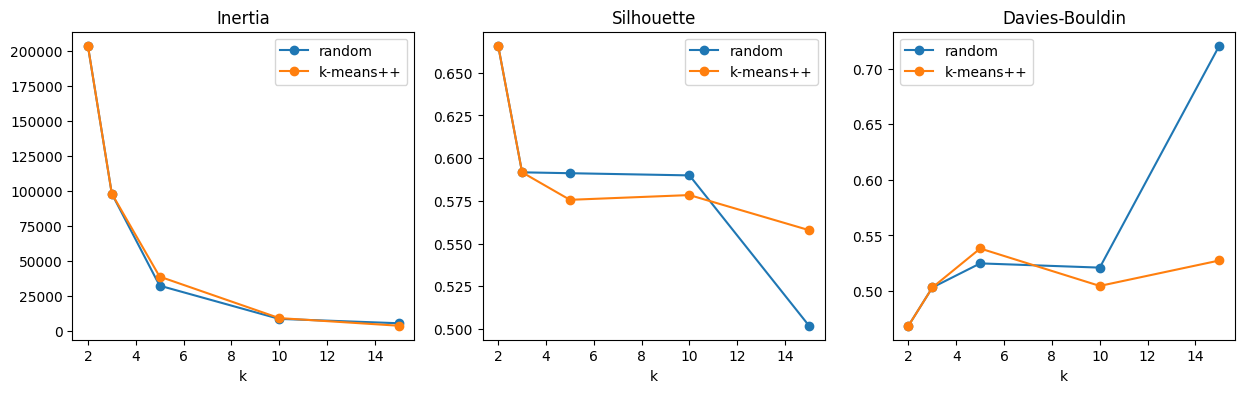

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for init in inits:
    subset = results[results['init'] == init]
    axes[0].plot(subset['k'], subset['Inertia'], marker='o', label=init)
    axes[1].plot(subset['k'], subset['Silhouette'], marker='o', label=init)
    axes[2].plot(subset['k'], subset['Davies-Bouldin'], marker='o', label=init)
for ax, title in zip(axes, ["Inertia", "Silhouette", "Davies-Bouldin"]):
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.legend()
plt.show()

Findings:
- K-means drops faster the K-means++ initially at k=5; but K-means++becomes slightly better after k=11
- Silhouette and Davies-Bouldin scores get worse as K increases suggesting that the social media addiction risk scores do not form clearly separated groups
- Random and k-means++ give identical results for k=2 and k=3 (ARI = 1.0), but disagree with higher k values. (ARI 0.7 at k=5, about 0.93 to 0.88 at k=10 and k=15)

## Agglomerative Clustering

### Install Dependencies

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as shc

### Data Cleaning

In [114]:
df = pd.read_csv("../../datasets/social_media_dopamine_productivity.csv", header=None)

#Cleaning
row = df.iloc[0].tolist()
row.insert(57, "mood_dependency_on_sm_score")
row.remove("notes")
df.columns = row
df.drop(index=0, axis=0, inplace=True)

df=df.drop(['data_source','synthetic_flag'], axis=1)
for col in df.columns:
    converted = pd.to_numeric(df[col], errors='coerce')
    if converted.notna().sum() == df[col].notna().sum():
        df[col] = converted
print("First 3 records:", df.head(3))

First 3 records:   participant_id  age age_group  gender race_ethnicity nationality  \
1          P0001   16     13-17  Female    South Asian      Indian   
2          P0002   17     13-17    Male     East Asian     Chinese   
3          P0003   15     13-17  Female  Black/African    Nigerian   

  country_of_residence education_level employment_status occupation_category  \
1                India     High school           Student           Education   
2                China     High school           Student           Education   
3              Nigeria     High school           Student           Education   

   ... mood_dependency_on_sm  mood_dependency_on_sm_score  \
1  ...                   Yes                            9   
2  ...                   Yes                           10   
3  ...                   Yes                            8   

   withdrawal_attempt_count longest_detox_days detox_relapse_reason  \
1                         2                  3              Bored

### Data Preparation

In [115]:
#Drop variables
features = df.select_dtypes(include='number').drop(columns=['sm_addiction_risk_score', 'age'])

#Scaling 
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

In [116]:
#Reducing dimesions using Prinicpal Component Analysis for easier visualisation
pca = PCA(n_components = 2)
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca)
df_pca.columns = ['PC1', 'PC2']

### Dendogram

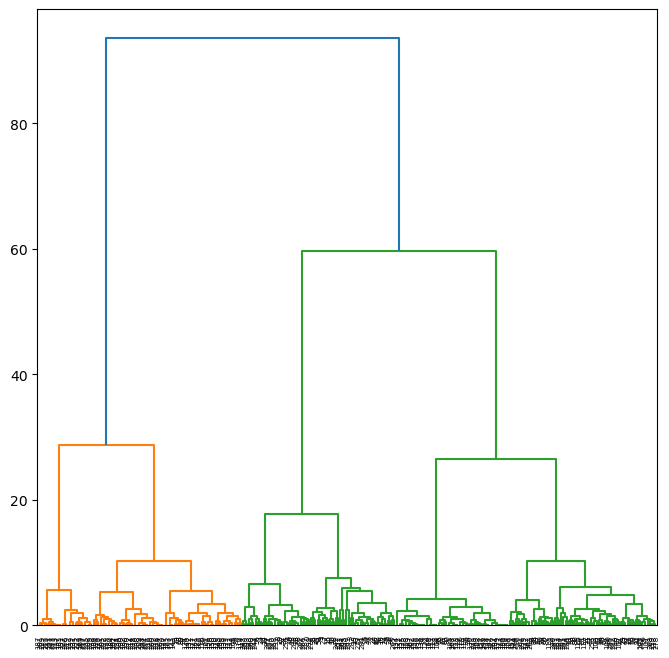

In [117]:
#Plotting dendrogram
plt.figure(figsize =(8, 8))
Dendrogram = shc.dendrogram((shc.linkage(df_scaled, method ='ward')))

### Clustering for different values of n clusters

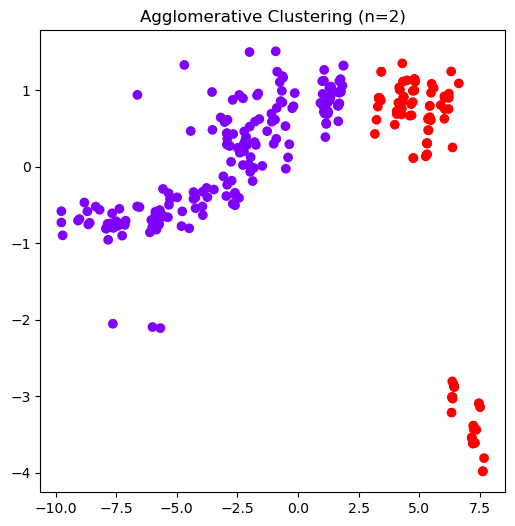

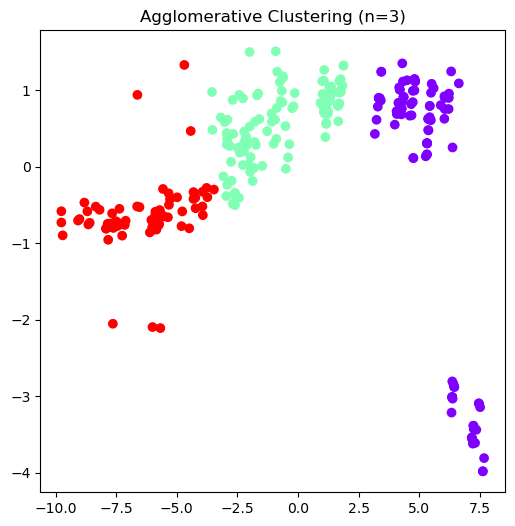

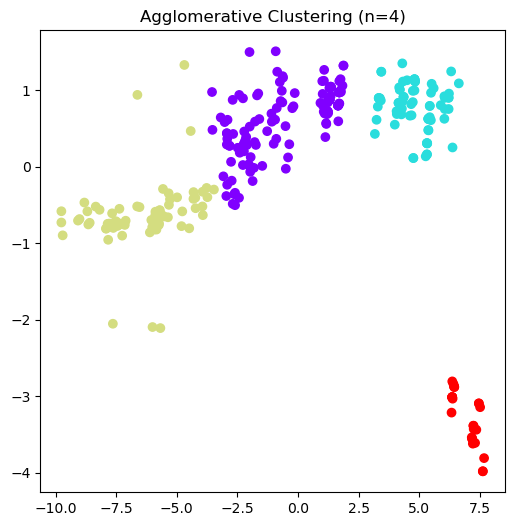

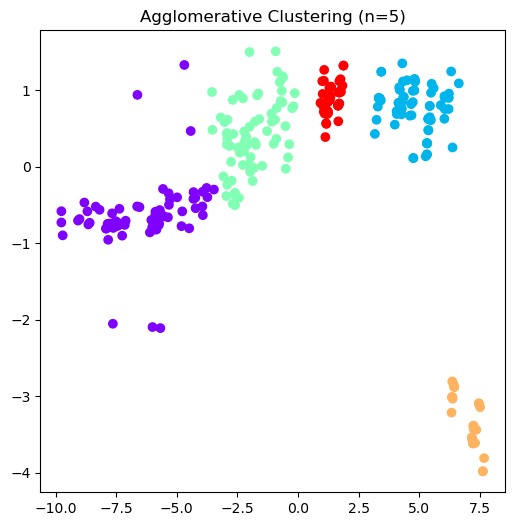

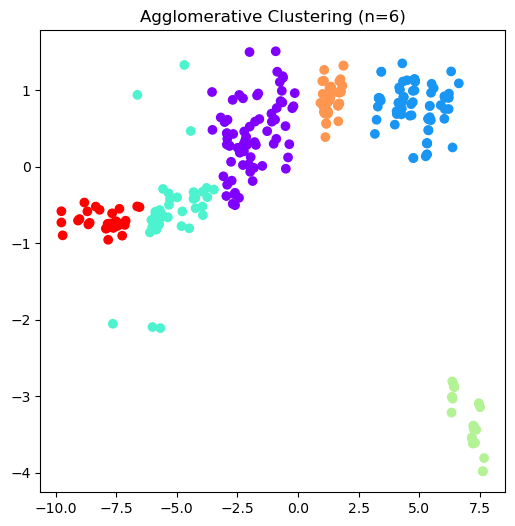

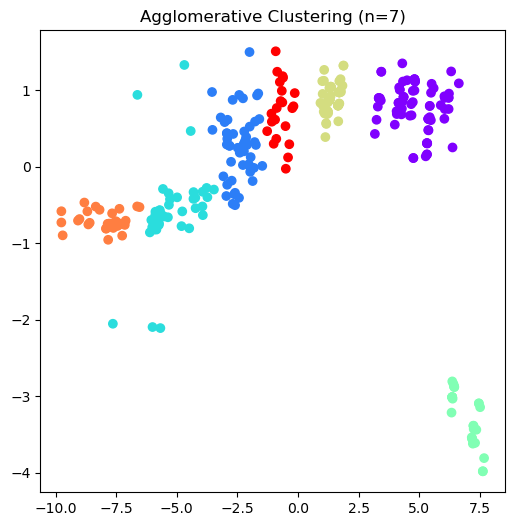

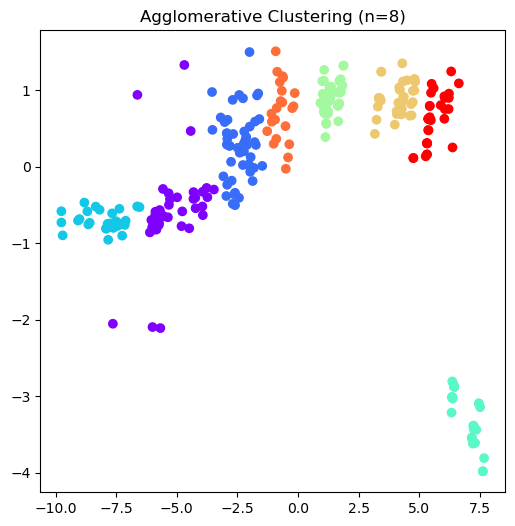

In [118]:
for n in range(2, 9):  #n range 2-8
    model = AgglomerativeClustering(n_clusters=n)  #default linkage ward
    labels = model.fit_predict(df_scaled)

    plt.figure(figsize=(6, 6))
    plt.scatter(df_pca['PC1'], df_pca['PC2'], c=labels, cmap='rainbow')
    plt.title(f'Agglomerative Clustering (n={n})')

    plt.show()

### Clustering for different linkages

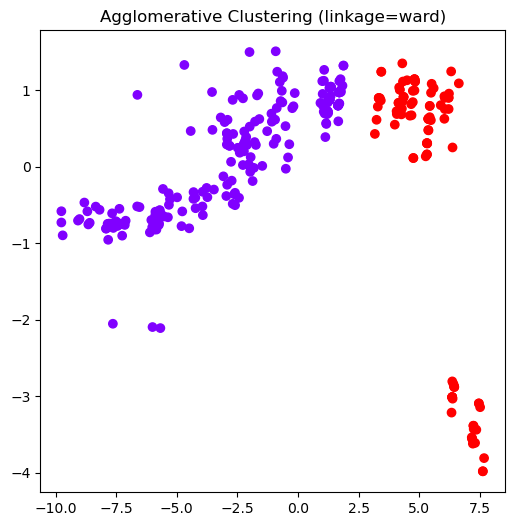

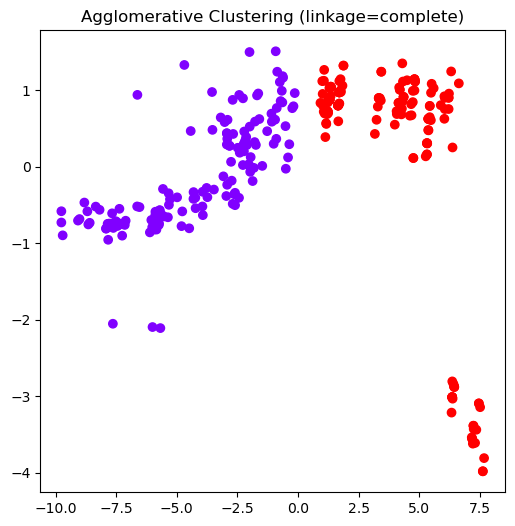

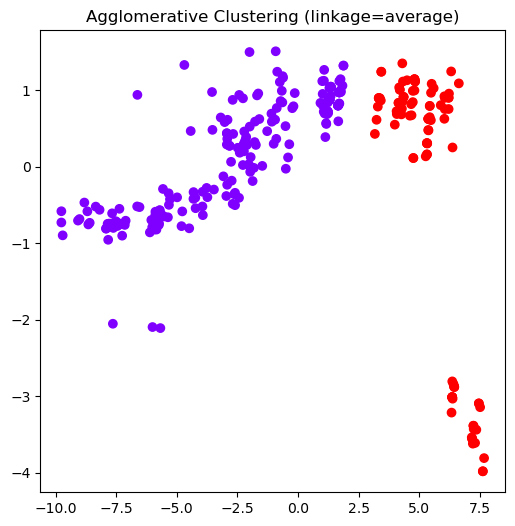

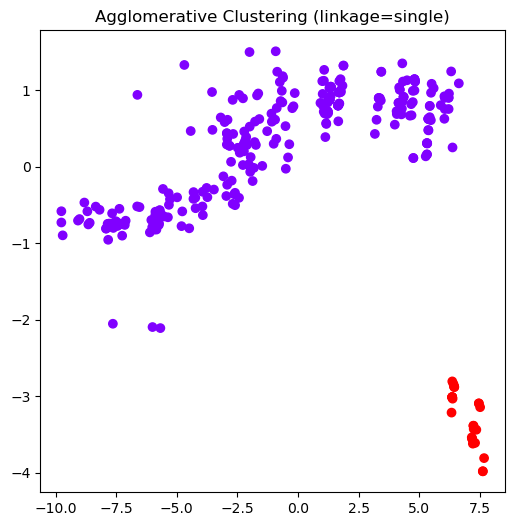

In [119]:
linkages = ['ward', 'complete', 'average', 'single']

for l in linkages: 
    model = AgglomerativeClustering(linkage=l)  #n_clusters default 2
    labels = model.fit_predict(df_scaled) 

    plt.figure(figsize=(6, 6))
    plt.scatter(df_pca['PC1'], df_pca['PC2'], c=labels, cmap='rainbow')
    plt.title(f'Agglomerative Clustering (linkage={l})')
    plt.show()

### Evaluating the variations of n and linkages
#### Using Silhouette Score, Davies Bouldin Score and Adjusted Rand Score

In [120]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Compare across everything
n = [2, 3, 4, 5, 6, 7, 8]
linkages = ['ward', 'complete', 'average', 'single']

agg_models = {
    (n, linkage): AgglomerativeClustering(n_clusters=n, linkage=linkage).fit(df_scaled)
    for n in n for linkage in linkages
}

In [ ]:
agg_results = pd.DataFrame([
    {
        "n": n,
        "linkage": linkage,
        "Silhouette": silhouette_score(df_scaled, model.labels_), #how close points are within own cluster (1 to -1)
        "Davies-Bouldin": davies_bouldin_score(df_scaled, model.labels_), #compares similar clusters (0 to inf)
        "Smallest cluster": np.bincount(model.labels_).min(),
    }
    for (n, linkage), model in agg_models.items()
])

agg_results

,n,linkage,Silhouette,Davies-Bouldin,Smallest cluster
0,2,ward,0.497795,0.658917,99
1,2,complete,0.558675,0.641599,146
2,2,average,0.497795,0.658917,99
3,2,single,0.357005,0.584650,27
4,3,ward,0.518029,0.653469,74
5,3,complete,0.469663,0.639289,67
6,3,average,0.515982,0.654237,73
7,3,single,0.018841,0.618212,1
8,4,ward,0.537285,0.556798,27
9,4,complete,0.500325,0.596968,27


In [122]:
from sklearn.cluster import KMeans

# ARI: comparing how close different methods are
agg_agreement = pd.DataFrame({
    n: {
        **{f"ward vs {linkage}": adjusted_rand_score(agg_models[(n, 'ward')].labels_, agg_models[(n, linkage)].labels_)
           for linkage in linkages[1:]},
        "ward vs K-means++": adjusted_rand_score(
            agg_models[(n, 'ward')].labels_,
            KMeans(n_clusters=n, init='k-means++', random_state=42).fit(df_scaled).labels_
        ),
    }
    for n in n
}).T
agg_agreement

,ward vs complete,ward vs average,ward vs single,ward vs K-means++
2,0.399286,1.000000,0.208077,0.399286
3,0.500696,0.990165,0.046999,0.980413
4,0.531279,0.989463,0.163402,0.532258
5,0.652212,0.990426,0.100926,0.708847
6,0.810044,0.971335,0.091691,0.672539
7,0.733014,0.891030,0.313726,0.913471
8,0.650083,0.768303,0.467641,0.815083


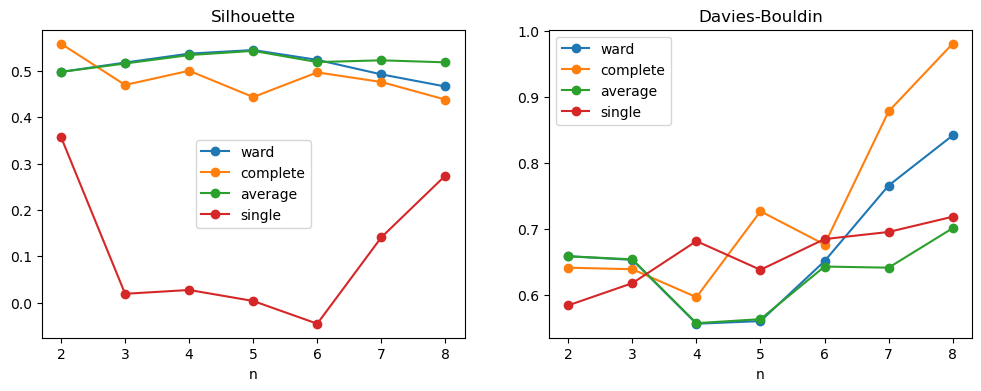

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for linkage in linkages:
    subset = agg_results[agg_results['linkage'] == linkage]
    axes[0].plot(subset['n'], subset['Silhouette'], marker='o', label=linkage)
    axes[1].plot(subset['n'], subset['Davies-Bouldin'], marker='o', label=linkage)
for ax, title in zip(axes, ["Silhouette", "Davies-Bouldin"]):
    ax.set_title(title)
    ax.set_xlabel("n")
    ax.legend()
plt.show()

Findings
- Silhouette and Davies-Bouldin Scores seem to generally peak around n = 5-6
- For Silhouette scores, single linkage has a much lower score than the rest, which indicates the clusters are very spread apart
- Davies-Bouldin vary greatly across linkages, but generally start to increase from n = 8, which suggests that clusters are comparatively more similar as n increases
- ARI values indicate the algorithms get more similar as n increases, and show that ward and average linkage perform very similarly until after n = 6